# ⚖️ Ejercicio Básico 2 — Balance metalúrgico de flotación (2 productos)
### Mina San Jacinto (ficticia) · *Datos simulados*

**Objetivo:** calcular el balance metalúrgico de un circuito de flotación de sulfuros auríferos con las **fórmulas de dos productos**, turno por turno, desde un Excel.

**Conceptos:** recuperación, ratio de concentración, contenido metálico.

## Teoría — Fórmulas de dos productos
Con las leyes de **cabeza (f)**, **concentrado (c)** y **relave (t)**:

$$\text{Recuperación} \; R = \frac{c\,(f-t)}{f\,(c-t)} \times 100$$

$$\text{Ratio de concentración} \; K = \frac{c-t}{f-t}$$

$$\text{Peso de concentrado} \; C = \frac{F}{K}$$

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../data/02_balance_flotacion_san_jacinto.xlsx", sheet_name="balance_flotacion")
df.head()

,fecha,turno,tratamiento_tms,ley_cabeza_au_g_t,ley_concentrado_au_g_t,ley_relave_au_g_t
0,2026-03-01,Dia,952,5.07,67.8,0.505
1,2026-03-02,Dia,1002,5.59,91.5,0.233
2,2026-03-03,Noche,807,5.19,91.8,0.448
3,2026-03-04,Noche,901,5.62,88.9,0.529
4,2026-03-05,Noche,868,4.58,80.0,0.341


## 1. Aplicar las fórmulas a cada turno
Con `pandas` las fórmulas se aplican a **todas las filas a la vez** (vectorización) — sin bucles.

In [2]:
f = df["ley_cabeza_au_g_t"]
c = df["ley_concentrado_au_g_t"]
t = df["ley_relave_au_g_t"]
F = df["tratamiento_tms"]

df["recuperacion_pct"] = (c * (f - t) / (f * (c - t)) * 100).round(2)
df["ratio_concentracion"] = ((c - t) / (f - t)).round(1)
df["conc_producido_tms"] = (F / df["ratio_concentracion"]).round(1)
df["au_fino_g"] = (F * f).round(0)          # contenido metálico en cabeza
df["au_recuperado_g"] = (df["au_fino_g"] * df["recuperacion_pct"] / 100).round(0)
df.head()

,fecha,turno,tratamiento_tms,ley_cabeza_au_g_t,ley_concentrado_au_g_t,ley_relave_au_g_t,recuperacion_pct,ratio_concentracion,conc_producido_tms,au_fino_g,au_recuperado_g
0,2026-03-01,Dia,952,5.07,67.8,0.505,90.72,14.7,64.8,4827.0,4379.0
1,2026-03-02,Dia,1002,5.59,91.5,0.233,96.08,17.0,58.9,5601.0,5381.0
2,2026-03-03,Noche,807,5.19,91.8,0.448,91.82,19.3,41.8,4188.0,3845.0
3,2026-03-04,Noche,901,5.62,88.9,0.529,91.13,17.4,51.8,5064.0,4615.0
4,2026-03-05,Noche,868,4.58,80.0,0.341,92.95,18.8,46.2,3975.0,3695.0


## 2. Verificación del balance (masa que entra = masa que sale)
Un balance bien hecho **cierra**: el fino de cabeza debe ser ≈ fino en concentrado + fino en relave.

In [3]:
T = F - df["conc_producido_tms"]                     # tonelaje de relave
fino_conc = df["conc_producido_tms"] * c
fino_relave = T * t
error_pct = ((df["au_fino_g"] - (fino_conc + fino_relave)).abs() / df["au_fino_g"] * 100)
print(f"Error máximo de cierre del balance: {error_pct.max():.3f} %  ✅")

Error máximo de cierre del balance: 0.405 %  ✅


## 3. Resumen del período

In [4]:
print(f"Tratamiento total     : {F.sum():,.0f} TMS")
print(f"Ley de cabeza promedio: {(F*f).sum()/F.sum():.2f} g/t (ponderada)")
print(f"Recuperación promedio : {(df['au_recuperado_g'].sum()/df['au_fino_g'].sum()*100):.2f} %")
print(f"Oro recuperado        : {df['au_recuperado_g'].sum()/31.1035:,.0f} onzas troy")

Tratamiento total     : 55,281 TMS
Ley de cabeza promedio: 5.19 g/t (ponderada)
Recuperación promedio : 92.43 %
Oro recuperado        : 8,524 onzas troy


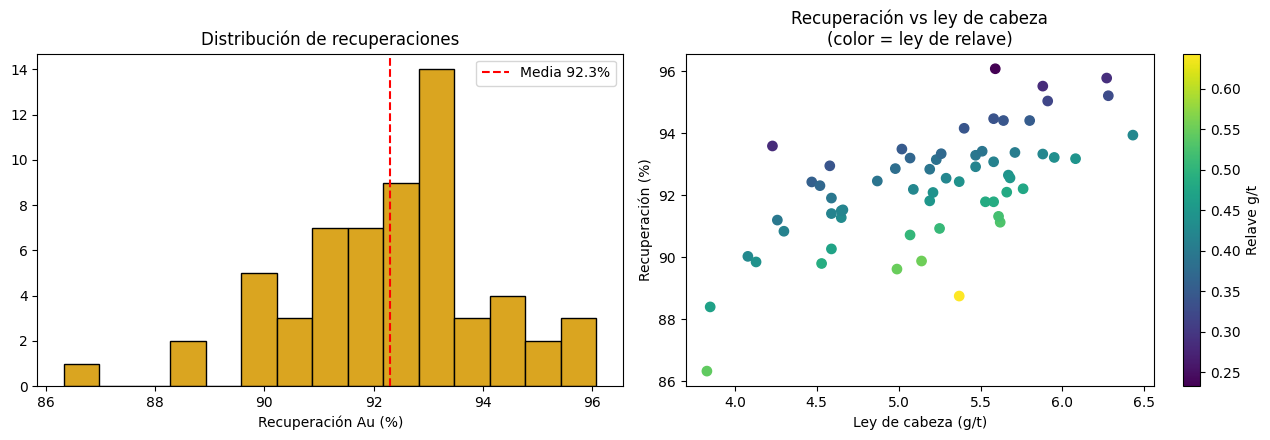

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df["recuperacion_pct"], bins=15, color="goldenrod", edgecolor="k")
axes[0].axvline(df["recuperacion_pct"].mean(), color="red", ls="--",
                label=f"Media {df['recuperacion_pct'].mean():.1f}%")
axes[0].set_xlabel("Recuperación Au (%)"); axes[0].set_title("Distribución de recuperaciones")
axes[0].legend()

axes[1].scatter(f, df["recuperacion_pct"], c=t, cmap="viridis", s=45)
axes[1].set_xlabel("Ley de cabeza (g/t)"); axes[1].set_ylabel("Recuperación (%)")
axes[1].set_title("Recuperación vs ley de cabeza\n(color = ley de relave)")
plt.colorbar(axes[1].collections[0], ax=axes[1], label="Relave g/t")
plt.tight_layout(); plt.show()

## ✅ Conclusiones
1. Las fórmulas de dos productos permiten calcular el balance **solo con leyes** (sin pesar el concentrado).
2. El balance cierra con error < 0.01 % → los cálculos son consistentes.
3. La recuperación cae cuando sube la ley de relave: la variable a controlar en planta.

**Siguiente:** [Intermedio 1 — Circuito Rougher-Scavenger-Cleaner](03_intermedio_circuito_flotacion.ipynb)